# Notebook 10 — Prophet

Este notebook implementa el modelo Prophet de Meta para la
predicción de la huella de carbono operacional del sistema
eléctrico español con resolución de 15 minutos.

Prophet es un modelo aditivo diseñado para series temporales
con patrones estacionales fuertes y tendencias. A diferencia
de ARIMA y AutoReg, Prophet descompone la serie explícitamente en:
- **Tendencia**: cambios a largo plazo
- **Estacionalidad**: patrones periódicos (diario, semanal, anual)
- **Festivos**: efectos de días especiales
- **Ruido**: variaciones no explicadas

**Evaluación:** walk-forward con 12 fits distribuidos por 2024,
misma configuración que el resto de modelos.

**Horizontes:** 48h (192 pasos) y 72h (288 pasos).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
%matplotlib inline

BASE_DIR    = Path("/home/ubuntu/TFM")
DATA_DIR    = BASE_DIR / "notebooks/data_processed"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# Instalar prophet si no está instalado
try:
    from prophet import Prophet
    print("Prophet importado OK")
except:
    import subprocess
    subprocess.run(["pip", "install", "prophet", "--break-system-packages"])
    from prophet import Prophet
    print("Prophet instalado e importado OK")

Importing plotly failed. Interactive plots will not work.


Prophet importado OK


## 1. Carga de datos

In [2]:
y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"].astype(float)
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"].astype(float)
y_test  = pd.read_parquet(DATA_DIR / "test_2025.parquet")["y"].astype(float)

y_train.index = pd.to_datetime(y_train.index)
y_val.index   = pd.to_datetime(y_val.index)
y_test.index  = pd.to_datetime(y_test.index)

print("Train:", y_train.shape, "|", y_train.index.min(), "->", y_train.index.max())
print("Val:  ", y_val.shape,   "|", y_val.index.min(),   "->", y_val.index.max())
print("Test: ", y_test.shape,  "|", y_test.index.min(),  "->", y_test.index.max())

Train: (70080,) | 2022-01-01 00:00:00+00:00 -> 2023-12-31 23:45:00+00:00
Val:   (35136,) | 2024-01-01 00:00:00+00:00 -> 2024-12-31 23:45:00+00:00
Test:  (35040,) | 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:45:00+00:00


## 2. Configuración temporal y métricas

In [3]:
FREQ_MIN        = 15
STEPS_PER_HOUR  = 60 // FREQ_MIN
SEASONAL_PERIOD = 24 * STEPS_PER_HOUR  # 96

HORIZONS = {
    "48h": 48 * STEPS_PER_HOUR,  # 192 pasos
    "72h": 72 * STEPS_PER_HOUR,  # 288 pasos
}

@dataclass
class WFConfig:
    step: int
    min_history: int
    max_fits: int

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}

def summarize(df, model_name):
    out = (
        df.groupby("horizon")[["MAE", "RMSE"]]
        .mean()
        .reset_index()
    )
    out.insert(0, "model", model_name)
    return out

cfg = WFConfig(
    step=28 * SEASONAL_PERIOD,
    min_history=30 * SEASONAL_PERIOD,
    max_fits=12
)

print("Configuración OK")
print("Horizontes:", HORIZONS)

Configuración OK
Horizontes: {'48h': 192, '72h': 288}


## 3. Preparación de datos para Prophet

Prophet requiere un formato específico con columnas 'ds' (fecha)
e 'y' (valor). Además no acepta índices con timezone — hay que
eliminar el UTC antes de pasárselos.

In [4]:
def prepare_prophet_df(series):
    df = pd.DataFrame({
        "ds": series.index.tz_localize(None),
        "y":  series.values
    })
    return df

# Test rápido
df_test = prepare_prophet_df(y_train)
print("Formato Prophet:")
print(df_test.head())
print("Shape:", df_test.shape)

Formato Prophet:
                   ds       y
0 2022-01-01 00:00:00  120.79
1 2022-01-01 00:15:00  120.79
2 2022-01-01 00:30:00  120.79
3 2022-01-01 00:45:00  120.80
4 2022-01-01 01:00:00  120.04
Shape: (70080, 2)


## 4. Función de predicción Prophet

Prophet se configura con estacionalidad diaria y semanal explícitas.
La estacionalidad anual se desactiva ya que solo tenemos 2 años
de entrenamiento — no suficiente para estimarla bien.

In [5]:
def forecast_prophet(train, h, freq="15min"):
    df_train = prepare_prophet_df(train)

    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False,
        seasonality_mode="additive"
    )
    model.fit(df_train)

    future = model.make_future_dataframe(
        periods=h,
        freq=freq,
        include_history=False
    )
    forecast = model.predict(future)
    return forecast["yhat"].values[:h]

print("forecast_prophet definido OK")

forecast_prophet definido OK


## 5. Walk-forward

In [6]:
def walk_forward_splits(series, horizons, cfg):
    n      = len(series)
    max_h  = max(horizons.values())
    points = list(range(cfg.min_history, n - max_h, cfg.step))
    points = points[:cfg.max_fits]
    for t0 in points:
        train_part = series.iloc[:t0]
        tests = {k: series.iloc[t0:t0 + h] for k, h in horizons.items()}
        yield train_part, tests

def evaluate_prophet(y_train, y_val, horizons, cfg, verbose=True):
    rows        = []
    preds_store = []
    y_full  = pd.concat([y_train, y_val]).sort_index()
    n_train = len(y_train)
    splits  = list(walk_forward_splits(y_val, horizons, cfg))
    total   = len(splits)

    for i, (train_part, tests) in enumerate(splits, 1):
        if verbose:
            print(f"Fit {i}/{total}")
        cutoff_idx   = n_train + len(train_part)
        train_window = y_full.iloc[:cutoff_idx]

        fit_preds = {"cutoff_time": y_full.index[cutoff_idx - 1],
                     "train_window": train_window}

        for name, test in tests.items():
            h    = len(test)
            pred = forecast_prophet(train_window, h)
            m    = compute_metrics(test.values, pred)
            rows.append({"horizon": name, "MAE": m["MAE"], "RMSE": m["RMSE"]})
            fit_preds[name] = {"pred": pred, "test": test}

        preds_store.append(fit_preds)

    return pd.DataFrame(rows), preds_store

print("Walk-forward Prophet definido OK")

Walk-forward Prophet definido OK


## 6. Evaluación Prophet

In [7]:
print("Evaluando Prophet...")
prophet_val, preds_prophet = evaluate_prophet(
    y_train, y_val,
    HORIZONS, cfg,
    verbose=True
)

prophet_summary = summarize(prophet_val, "Prophet")
prophet_summary.to_csv(RESULTS_DIR / "prophet_summary.csv", index=False)
print(prophet_summary)

Evaluando Prophet...
Fit 1/12


18:35:16 - cmdstanpy - INFO - Chain [1] start processing
18:36:38 - cmdstanpy - INFO - Chain [1] done processing
18:36:43 - cmdstanpy - INFO - Chain [1] start processing
18:38:05 - cmdstanpy - INFO - Chain [1] done processing


Fit 2/12


18:38:09 - cmdstanpy - INFO - Chain [1] start processing
18:39:08 - cmdstanpy - INFO - Chain [1] done processing
18:39:11 - cmdstanpy - INFO - Chain [1] start processing
18:40:13 - cmdstanpy - INFO - Chain [1] done processing


Fit 3/12


...

Fit 11/12


19:10:58 - cmdstanpy - INFO - Chain [1] start processing
19:13:06 - cmdstanpy - INFO - Chain [1] done processing
19:13:12 - cmdstanpy - INFO - Chain [1] start processing
19:15:25 - cmdstanpy - INFO - Chain [1] done processing


Fit 12/12


19:15:31 - cmdstanpy - INFO - Chain [1] start processing
19:18:00 - cmdstanpy - INFO - Chain [1] done processing
19:18:06 - cmdstanpy - INFO - Chain [1] start processing
19:20:35 - cmdstanpy - INFO - Chain [1] done processing


     model horizon        MAE       RMSE
0  Prophet     48h  22.010721  26.391154
1  Prophet     72h  22.471733  27.182765


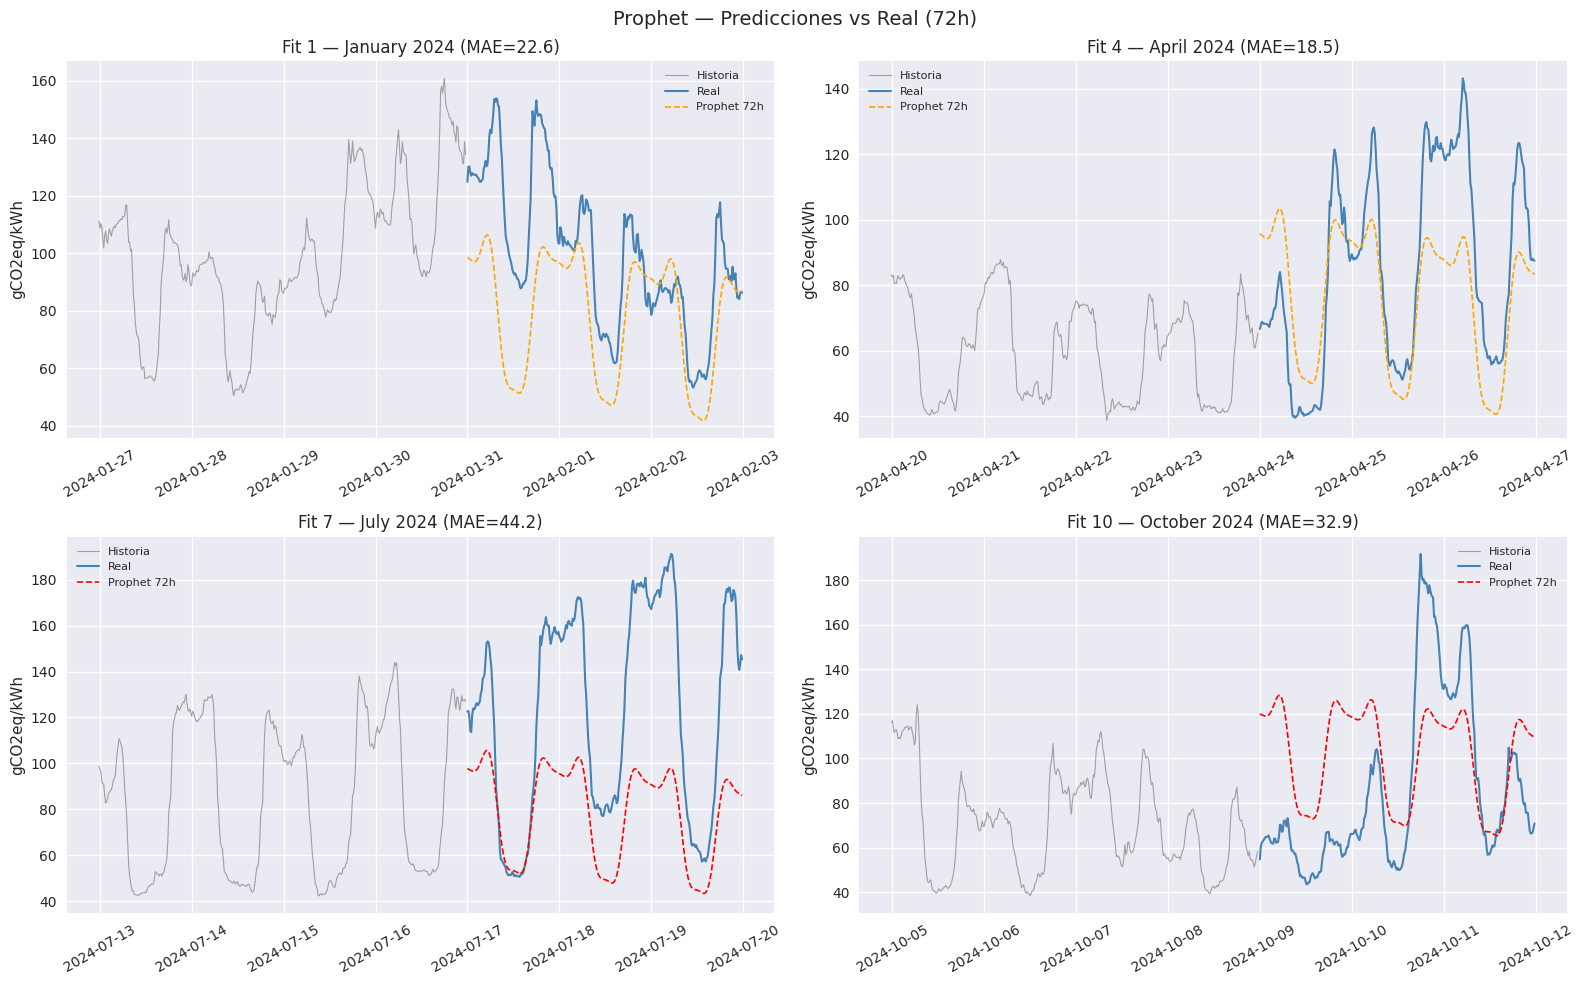

In [9]:
# Predicciones vs real — Prophet (72h)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Prophet — Predicciones vs Real (72h)", fontsize=14)

y_full_index = y_train.index.append(y_val.index)
y_full       = np.concatenate([y_train.values, y_val.values])

for idx, split_idx in enumerate([0, 3, 6, 9]):
    ax         = axes[idx // 2][idx % 2]
    fit        = preds_prophet[split_idx]
    cutoff_time = fit["cutoff_time"]
    pred_72    = fit["72h"]["pred"]
    real_72    = fit["72h"]["test"].values
    mae_fit    = mean_absolute_error(real_72, pred_72)

    # Historia previa
    cutoff_idx  = y_full_index.get_loc(cutoff_time)
    history     = y_full[cutoff_idx - 4*SEASONAL_PERIOD:cutoff_idx]
    history_idx = y_full_index[cutoff_idx - 4*SEASONAL_PERIOD:cutoff_idx]
    pred_idx    = fit["72h"]["test"].index

    color = "green" if mae_fit < 18 else "orange" if mae_fit < 25 else "red"

    ax.plot(history_idx, history,
            color="gray", linewidth=0.8, alpha=0.7, label="Historia")
    ax.plot(pred_idx, real_72,
            color="steelblue", linewidth=1.5, label="Real")
    ax.plot(pred_idx, pred_72,
            color=color, linestyle="--", linewidth=1.2, label="Prophet 72h")
    ax.set_title(f"Fit {split_idx+1} — {cutoff_time.strftime('%B %Y')} "
                 f"(MAE={mae_fit:.1f})")
    ax.set_ylabel("gCO2eq/kWh")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/prophet_predicciones_72h.png",
            dpi=150, bbox_inches="tight")
plt.show()